In [ ]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split
from torchvision import datasets, transforms
%matplotlib inline

In [ ]:
from torchvision.datasets.mnist import FashionMNIST
dataset = FashionMNIST(root='fdata', download=True, transform=ToTensor())
test_dataset = FashionMNIST(root='fdata', train=False, transform=ToTensor())

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.1MB/s]


In [ ]:
val_size = 10000
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])
len(train_ds), len(val_ds)

(50000, 10000)

In [ ]:
batch_size=128

In [ ]:
train_loader = DataLoader(dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size*2, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size*2, num_workers=2, pin_memory=True)

images.shape: torch.Size([128, 1, 28, 28])


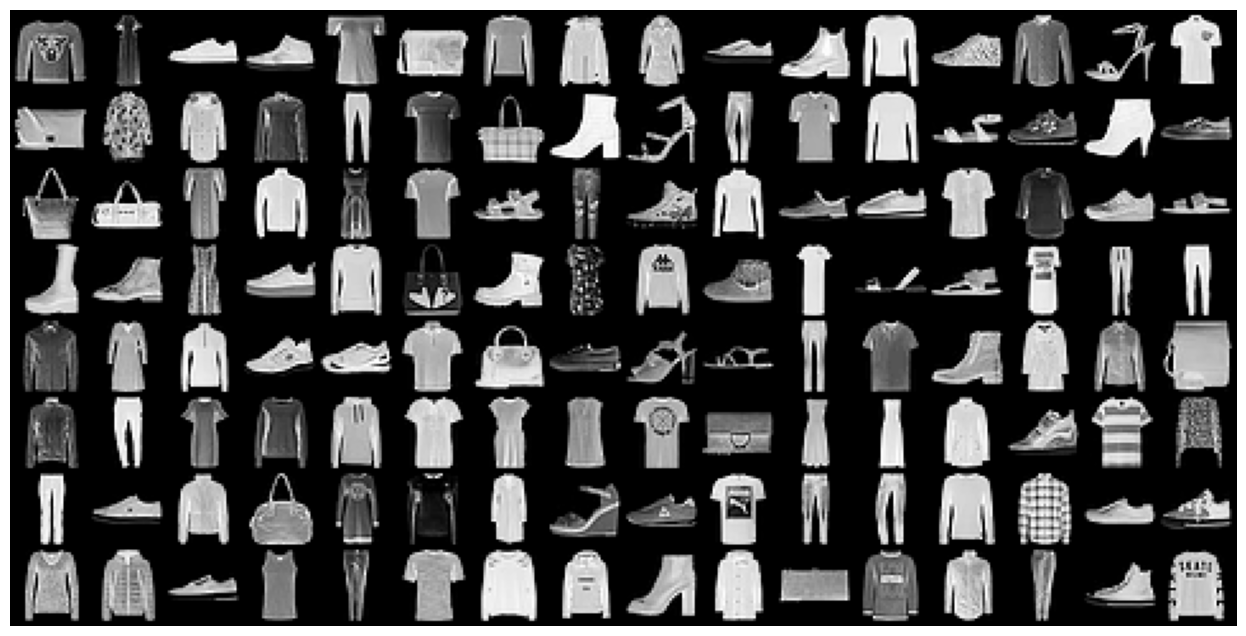

In [ ]:
for images, _ in train_loader:
  print('images.shape:', images.shape)
  plt.figure(figsize=(16,8))
  plt.axis('off')
  plt.imshow(make_grid(images, nrow=16).permute((1,2,0)))
  break

In [ ]:
def accuracy(outputs, labels):
  _, preds = torch.max(outputs, dim=1)
  return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [ ]:
class MnistModel(nn.Module):
  '''Feedforward neural network with 1 hidden layer'''
  def __init__(self, in_size, hidden_size1, hidden_size2, out_size):
      super().__init__()
      # hiddden layer 1
      self.linear1 = nn.Linear(in_size, hidden_size1)
      # hiddden layer 2
      self.linear2 = nn.Linear(hidden_size1, hidden_size2)
      # output layer
      self.linear3 = nn.Linear(hidden_size2, out_size)

      # Dropout
      self.dropout = nn.Dropout(0.2)

  def forward(self, xb):
    # Flatten image tensors
    xb = xb.view(xb.size(0), -1)
    # Get intermediate output using hidden layer 1
    out = self.linear1(xb)
    # Apply activation function
    out = F.relu(out)
    # Apply dropout
    out = self.dropout(out)
    # Get intermediate output using hidden layer 2
    out = self.linear2(out)
    # Apply activation function
    out = F.relu(out)
    # Apply dropout
    out = self.dropout(out)
    # Get predictions using output layer
    out = self.linear3(out)
    return out

  def training_step(self, batch):
    images, labels = batch
    out = self(images)                      # Generate predictions
    loss = F.cross_entropy(out, labels)     # Calculate loss
    return loss

  def validation_step(self, batch):
    images, labels = batch
    out = self(images)                        # Generate predictions
    loss = F.cross_entropy(out, labels)       # Calculate loss
    acc = accuracy(out, labels)               # Calculate accuracy
    return {'val_loss': loss.detach(), 'val_acc': acc}

  def validation_epoch_end(self, outputs):
    batch_losses = [x['val_loss'] for x in outputs]
    epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
    batch_accs = [x['val_acc'] for x in outputs]
    epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
    return {'val_loss': epoch_loss.item(), 'val_acc':epoch_acc.item()}

  def epoch_end(self, epoch, results):
      print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, results['val_loss'], results['val_acc']))

In [ ]:
input_size = 784
hidden_size1 = 64
hidden_size2 = 128
num_classes = 10

In [ ]:
model = MnistModel(input_size, hidden_size1, hidden_size2, out_size = num_classes)

In [ ]:
model

MnistModel(
  (linear1): Linear(in_features=784, out_features=64, bias=True)
  (linear2): Linear(in_features=64, out_features=128, bias=True)
  (linear3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [ ]:
for t in model.parameters():
  print(t.shape)

torch.Size([64, 784])
torch.Size([64])
torch.Size([128, 64])
torch.Size([128])
torch.Size([10, 128])
torch.Size([10])


In [ ]:
for images, labels in train_loader:
  outputs = model(images)
  loss = F.cross_entropy(outputs, labels)
  print('loss:', loss.item())
  break

print('outputs.shape:', outputs.shape)
print('Sample outputs :\n', outputs[:2].data)

loss: 2.2881357669830322
outputs.shape: torch.Size([128, 10])
Sample outputs :
 tensor([[-0.1502,  0.0987,  0.0259, -0.0200, -0.0759, -0.0698,  0.0374, -0.0023,
         -0.0999, -0.0305],
        [-0.0855,  0.0693, -0.0375,  0.0220, -0.0402, -0.0754,  0.1123, -0.0426,
         -0.2070,  0.0099]])


In [ ]:
torch.cuda.is_available()
def get_default_device():
  ''' Pick GPU if available, else CPU '''
  if torch.cuda.is_available():
    return torch.device('cuda')
  else:
    return torch.device('CPU')

In [ ]:
device =  get_default_device()
device

device(type='cuda')

In [ ]:
def to_device(data, device):
  ''' Move tensor(s) to chosen device'''
  if isinstance(data, (list,tuple)):
    return [to_device(x, device) for x in data]
  return data.to(device, non_blocking=True)

In [ ]:
for images, labels in train_loader:
  print(images.shape)
  images = to_device(images, device)
  print(images.device)
  break

torch.Size([128, 1, 28, 28])
cuda:0


In [ ]:
class DeviceDataLoader():
  ''' Wrap a data loader to move data to a device'''
  def __init__(self, dl, device):
    self.dl = dl
    self.device = device

  def __iter__(self):
    '''Yield a batch of data after moving it to device'''
    for b in self.dl:
      yield to_device(b, self.device)

  def __len__(self):
    ''' Number of batches'''
    return len(self.dl)

In [ ]:
train_loader = DeviceDataLoader(train_loader, device)
val_loader = DeviceDataLoader(val_loader, device)

In [ ]:
for xb, yb in val_loader:
  print('xb.device:', xb.device)
  print('yb:', yb)
  break

xb.device: cuda:0
yb: tensor([6, 0, 3, 4, 7, 6, 8, 7, 8, 5, 1, 3, 5, 0, 7, 0, 2, 6, 6, 8, 1, 7, 8, 4,
        2, 8, 6, 4, 2, 8, 6, 4, 2, 9, 8, 2, 4, 0, 0, 4, 0, 4, 6, 3, 9, 8, 5, 9,
        5, 6, 1, 3, 0, 1, 4, 8, 3, 3, 1, 0, 6, 1, 0, 3, 2, 1, 1, 8, 6, 6, 6, 8,
        6, 9, 2, 0, 8, 4, 9, 7, 3, 3, 5, 2, 4, 5, 9, 1, 5, 0, 0, 2, 0, 6, 9, 6,
        0, 8, 1, 6, 3, 2, 0, 7, 0, 4, 6, 3, 7, 6, 7, 5, 2, 5, 7, 4, 8, 3, 8, 4,
        9, 2, 1, 6, 0, 6, 2, 9, 3, 2, 0, 5, 7, 6, 2, 1, 7, 0, 9, 4, 5, 9, 3, 1,
        8, 8, 9, 9, 2, 7, 7, 2, 6, 7, 2, 1, 7, 3, 5, 9, 2, 7, 7, 1, 5, 7, 0, 6,
        5, 1, 4, 0, 3, 3, 9, 1, 1, 0, 3, 7, 5, 2, 7, 9, 2, 3, 4, 5, 8, 5, 3, 6,
        0, 9, 9, 7, 7, 0, 3, 1, 3, 6, 3, 2, 6, 2, 7, 7, 5, 4, 6, 4, 2, 0, 3, 5,
        7, 2, 2, 1, 8, 1, 9, 2, 3, 6, 1, 7, 3, 9, 6, 4, 5, 5, 1, 9, 6, 4, 7, 4,
        5, 3, 5, 4, 0, 4, 6, 1, 3, 3, 1, 6, 6, 0, 9, 1], device='cuda:0')


In [ ]:
def evaluate(model, val_loader):
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.Adam):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training phase
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        # Validation phase
        result = evaluate (model, val_loader)
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [ ]:
model = MnistModel(in_size=input_size,hidden_size1=hidden_size1, hidden_size2=hidden_size2, out_size=num_classes)
to_device(model, device)

MnistModel(
  (linear1): Linear(in_features=784, out_features=64, bias=True)
  (linear2): Linear(in_features=64, out_features=128, bias=True)
  (linear3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [ ]:
history = [evaluate(model, val_loader)]
history

[{'val_loss': 2.307637929916382, 'val_acc': 0.09550781548023224}]

In [ ]:
history1 = fit(10, 0.001,model,train_loader, val_loader)

Epoch [0], val_loss: 0.4951, val_acc: 0.8190
Epoch [1], val_loss: 0.4281, val_acc: 0.8437
Epoch [2], val_loss: 0.4102, val_acc: 0.8523
Epoch [3], val_loss: 0.3809, val_acc: 0.8632
Epoch [4], val_loss: 0.3732, val_acc: 0.8627
Epoch [5], val_loss: 0.3739, val_acc: 0.8626
Epoch [6], val_loss: 0.3441, val_acc: 0.8767
Epoch [7], val_loss: 0.3380, val_acc: 0.8750
Epoch [8], val_loss: 0.3250, val_acc: 0.8836
Epoch [9], val_loss: 0.3378, val_acc: 0.8765


In [ ]:
history2 = fit(10, 0.001,model,train_loader, val_loader)

Epoch [0], val_loss: 0.3184, val_acc: 0.8803
Epoch [1], val_loss: 0.3128, val_acc: 0.8837
Epoch [2], val_loss: 0.3042, val_acc: 0.8873
Epoch [3], val_loss: 0.3095, val_acc: 0.8828
Epoch [4], val_loss: 0.2993, val_acc: 0.8903
Epoch [5], val_loss: 0.3021, val_acc: 0.8894
Epoch [6], val_loss: 0.2886, val_acc: 0.8871
Epoch [7], val_loss: 0.2905, val_acc: 0.8909
Epoch [8], val_loss: 0.2918, val_acc: 0.8878
Epoch [9], val_loss: 0.2793, val_acc: 0.8984


In [ ]:
history3 = fit(5, 0.001,model,train_loader, val_loader)

Epoch [0], val_loss: 0.3098, val_acc: 0.8883
Epoch [1], val_loss: 0.3100, val_acc: 0.8861
Epoch [2], val_loss: 0.2978, val_acc: 0.8915
Epoch [3], val_loss: 0.2827, val_acc: 0.8988
Epoch [4], val_loss: 0.3025, val_acc: 0.8859


In [ ]:
history4 = fit(5, 0.001,model,train_loader, val_loader)

Epoch [0], val_loss: 0.2776, val_acc: 0.8977
Epoch [1], val_loss: 0.2850, val_acc: 0.8957
Epoch [2], val_loss: 0.2934, val_acc: 0.8962
Epoch [3], val_loss: 0.2942, val_acc: 0.8908
Epoch [4], val_loss: 0.2942, val_acc: 0.8862


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'Accuracy vs No. of epochs')

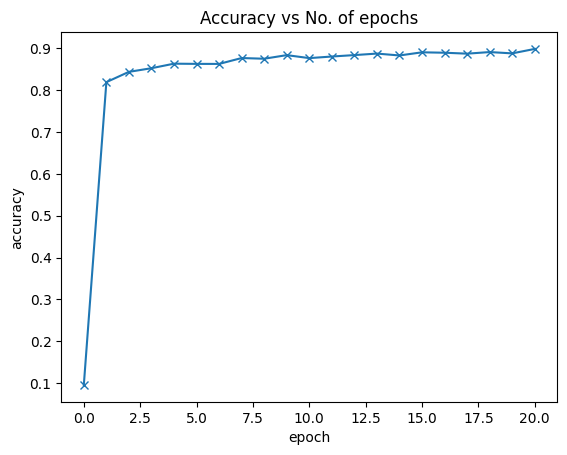

In [ ]:
history = history + history1 + history2 #+ history3 #+ history4
accuracies = [x['val_acc'] for x in history]
plt.plot(accuracies, '-x')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy vs No. of epochs')

Text(0.5, 1.0, 'Loss vs No. of epochs')

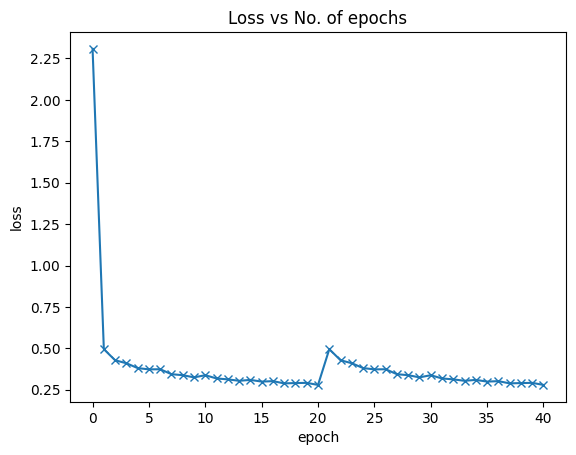

In [ ]:
history = history + history1 + history2 #+ history3 #+ history4
losses = [x['val_loss'] for x in history]
plt.plot(losses, '-x')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss vs No. of epochs')

Shape: torch.Size([1, 28, 28])
Label 9


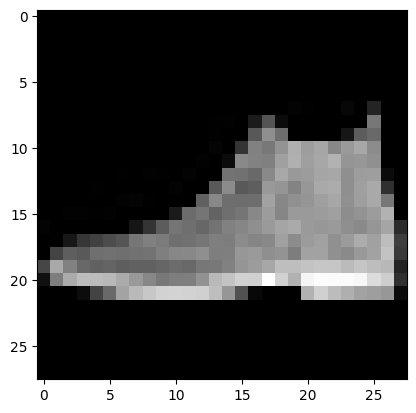

In [ ]:
img, label = test_dataset[0]
plt.imshow(img[0], cmap='gray')
print('Shape:', img.shape)
print('Label', label)

In [ ]:
img.unsqueeze(0).shape

torch.Size([1, 1, 28, 28])

In [ ]:
def predict_image(img, model):
    device = next(model.parameters()).device   # get model device

    img = img.unsqueeze(0).to(device)           # add batch dim + move to GPU

    model.eval()
    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, dim=1)

    return preds.item()

Label: 9 , Predicted: 9


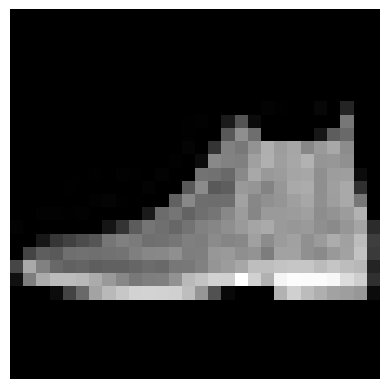

In [ ]:
img, label = test_dataset[0]

plt.imshow(img[0], cmap='gray')
plt.axis('off')

print('Label:', label, ', Predicted:', predict_image(img, model))

Shape: torch.Size([1, 28, 28])
Label 3


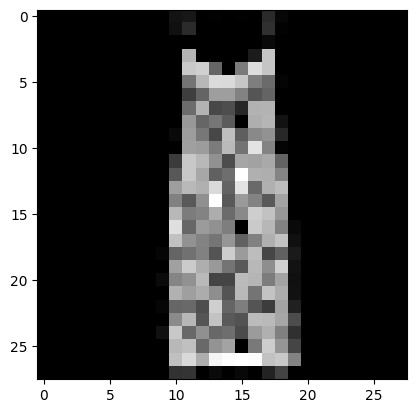

In [ ]:
img300, label300 = test_dataset[300]
plt.imshow(img300[0], cmap='gray')
print('Shape:', img300.shape)
print('Label', label300)

In [ ]:
img.unsqueeze(0).shape

torch.Size([1, 1, 28, 28])

In [ ]:
def predict_image(img, model):
    device = next(model.parameters()).device   # get model device

    img = img.unsqueeze(0).to(device)           # add batch dim + move to GPU

    model.eval()
    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, dim=1)

    return preds.item()

Label: 3 , Predicted: 3


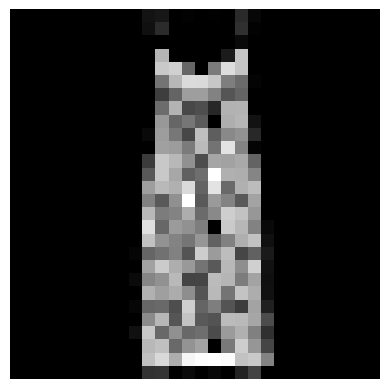

In [ ]:
img300, label300 = test_dataset[300]

plt.imshow(img300[0], cmap='gray')
plt.axis('off')

print('Label:', label300, ', Predicted:', predict_image(img300, model))

In [ ]:
def evaluate_accuracy(model, dataloader):
    device = next(model.parameters()).device
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)
            _, preds = torch.max(outputs, dim=1)

            correct += (preds == yb).sum().item()
            total += yb.size(0)

    accuracy = correct / total
    return accuracy


In [ ]:
test_acc = evaluate_accuracy(model, test_loader)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")


Test Accuracy: 0.8837 (88.37%)
